In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
# Load dataset
data = fetch_california_housing(as_frame=True)
df = data.frame

# Check for missing values
print(df.isnull().sum())
print(df.describe())

# Split features and target
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000

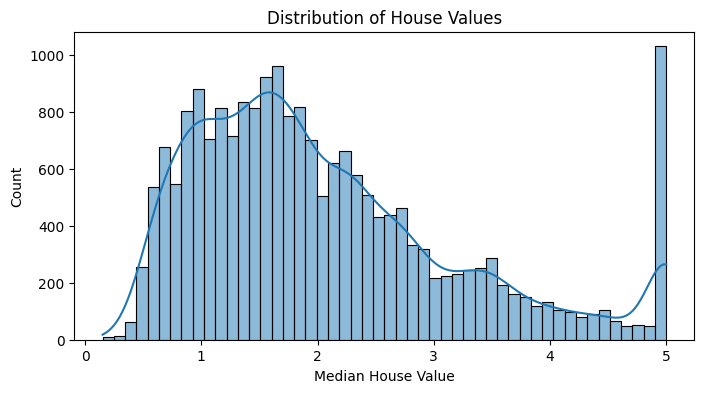

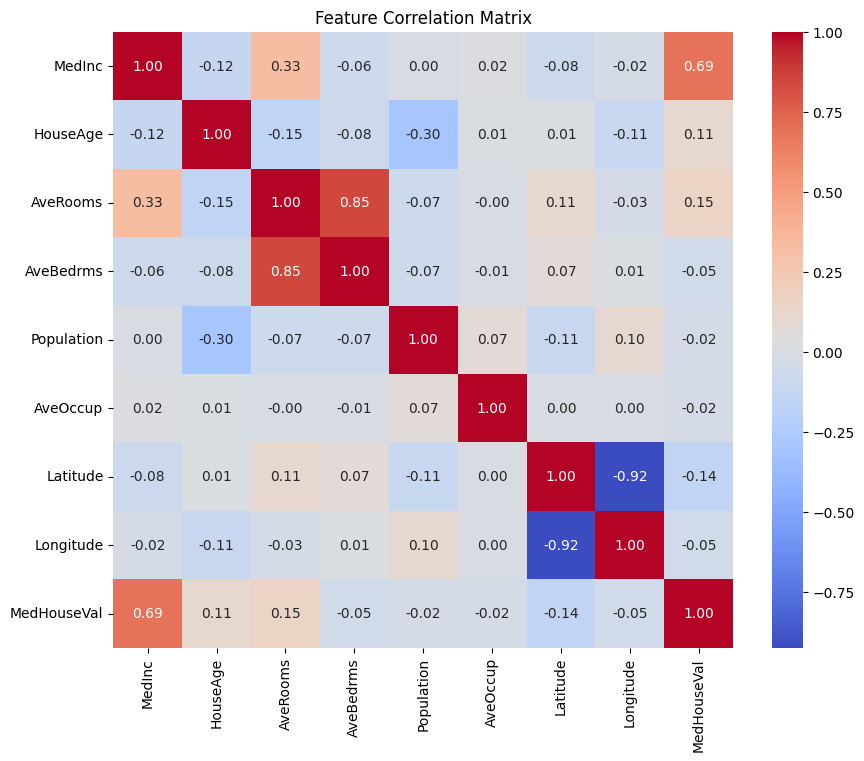

In [ ]:
# Distribution of target variable
plt.figure(figsize=(8, 4))
sns.histplot(y, bins=50, kde=True)
plt.title("Distribution of House Values")
plt.xlabel("Median House Value")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

# Model 2: Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)

In [ ]:
def evaluate(name, y_true, y_pred):
    print(f"\n--- {name} ---")
    print(f"R² Score:  {r2_score(y_true, y_pred):.4f}")
    print(f"MAE:       {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"RMSE:      {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")

evaluate("Linear Regression", y_test, lr_preds)
evaluate("Random Forest",     y_test, rf_preds)


--- Linear Regression ---
R² Score:  0.5758
MAE:       0.5332
RMSE:      0.7456

--- Random Forest ---
R² Score:  0.8053
MAE:       0.3274
RMSE:      0.5051


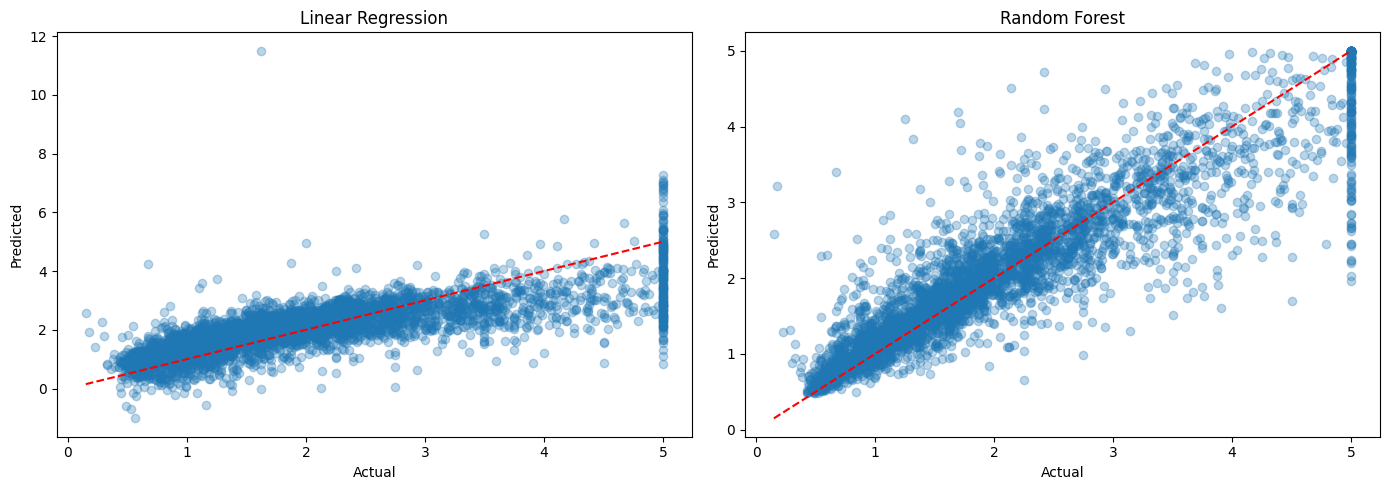

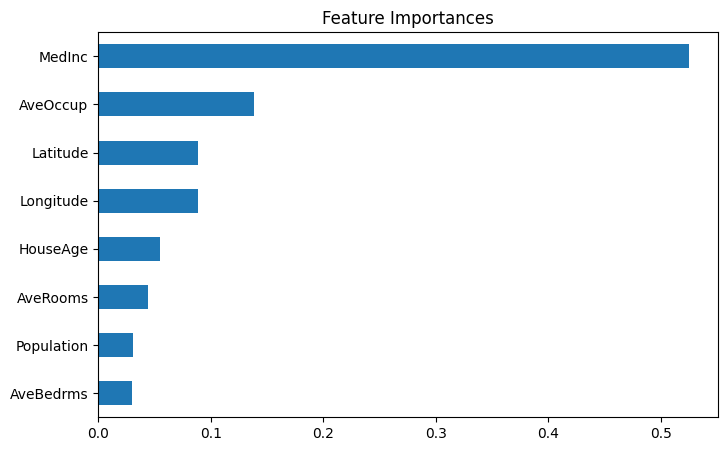

In [ ]:
# Actual vs Predicted for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, name in zip(axes,
                            [lr_preds, rf_preds],
                            ["Linear Regression", "Random Forest"]):
    ax.scatter(y_test, preds, alpha=0.3)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--')
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(name)

plt.tight_layout()
plt.show()

# Feature importance (Random Forest)
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh", figsize=(8, 5),
                               title="Feature Importances")
plt.show()